<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/RidgeRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_clean.csv")

In [37]:
X = df.drop(columns = 'RIDAGEYR').values
y = df['RIDAGEYR'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

def add_intercept(X):
  return np.column_stack ((np.ones(X.shape[0]), X))
scalar = StandardScaler()
X_train_s = scalar.fit_transform(X_train)
X_test_s = scalar.transform(X_test)

X_train_b = add_intercept(X_train_s)
X_test_b = add_intercept(X_test_s)
w = np.linalg.lstsq(X_train_b, y_train, rcond=None)[0]


In [38]:
def predict (X_b, w):
  return X_b @w

def rmse(y_true, y_pred):
  return np.sqrt(np.mean((y_true - y_pred)**2))

def mae(y_true, y_pred):
  return np.mean(np.abs(y_true - y_pred))

predicted = predict(X_test_b, w)
print("RMSE: ", rmse(y_test, predicted))
print("MAE: ", mae(y_test, predicted))

age_gap = predicted - y_test
print(f"\n Biological Age Gap: mean: {age_gap.mean():.2f}, std: {age_gap.std():.2f}")
for i in range(10):
  idx = random.randint(0, len(df)-1)
  y_true_sample = y[idx]
  X_single_sample_reshaped = X[idx].reshape(1, -1)
  predict_sample_b = add_intercept(X_single_sample_reshaped)
  predict_sample_one = predict(predict_sample_b, w)

  print(f"True age: {y_true_sample:.2f} | Predicted age: {predict_sample_one[0]:.2f}")


RMSE:  14.09952889753923
MAE:  10.73523028996278

 Biological Age Gap: mean: -0.22, std: 14.10
True age: 12.00 | Predicted age: 445.52
True age: 47.00 | Predicted age: 1022.85
True age: 16.00 | Predicted age: 459.49
True age: 13.00 | Predicted age: 415.67
True age: 39.00 | Predicted age: 879.68
True age: 1.00 | Predicted age: 526.43
True age: 8.00 | Predicted age: 377.70
True age: 11.00 | Predicted age: 463.06
True age: 68.00 | Predicted age: 937.83
True age: 60.00 | Predicted age: 562.75


In [50]:
def ridge_gradient_descent(X, y, alpha, eta, epochs = 5000):
  w  = np.zeros(X.shape[1])
  n = len(y)
  losses = []
  for epoch in range (epochs):
    predicts = X @ w
    error = predicts - y
    grad = (2/n) *X.T @ error
    grad[1:] += (2 * alpha/n) *w[1:]
    w -= eta * grad
    loss = np.mean(error**2) + alpha *np.sum(w[1:]**2)
    losses.append(loss)
  return w, losses

alphas = [0.01, 0.1, 1, 10, 100]
etas = [1e-3, 0.01, 0.1]
best_rmse = float('inf')
best_alpha = None
best_w = None
best_eta = etas[0]
for eta in etas:
  for alpha in alphas:
    w_ridge, losses = ridge_gradient_descent(X_train_b, y_train, alpha, eta)
    test_preds_r = X_test_b @ w_ridge
    rmse_ridge = rmse(y_test, test_preds_r)
    mae_ridge = mae(y_test, test_preds_r)
    gap = test_preds_r - y_test
    print(f"alpha = {alpha:<6.2f} RMSE= {rmse_ridge:.2f} Gap mean{gap.mean():.2f} std= {gap.std():.2f}")
    if rmse_ridge < best_rmse:
      best_rmse = rmse_ridge
      best_alpha = alpha
      best_w = w_ridge
      best_eta = eta
  print("\n")
print("\n")

print(f"Best alpha: {best_alpha} | Best RMSE: {best_rmse:.2f} | Best eta: {best_eta} \n")

for i in range(10):
  idx = random.randint(0, len(X_test_b)-1)
  pred = predict (X_test_b[idx], best_w)
  y_sample = y_test[idx]
  print(f"Actual: {y_sample:.2f} | Predicted: {pred:.2f}")

alpha = 0.01   RMSE= 14.22 Gap mean-0.24 std= 14.22
alpha = 0.10   RMSE= 14.22 Gap mean-0.24 std= 14.22
alpha = 1.00   RMSE= 14.22 Gap mean-0.24 std= 14.22
alpha = 10.00  RMSE= 14.22 Gap mean-0.24 std= 14.22
alpha = 100.00 RMSE= 14.23 Gap mean-0.24 std= 14.23


alpha = 0.01   RMSE= 14.10 Gap mean-0.22 std= 14.10
alpha = 0.10   RMSE= 14.10 Gap mean-0.22 std= 14.10
alpha = 1.00   RMSE= 14.10 Gap mean-0.22 std= 14.10
alpha = 10.00  RMSE= 14.10 Gap mean-0.23 std= 14.10
alpha = 100.00 RMSE= 14.11 Gap mean-0.23 std= 14.11


alpha = 0.01   RMSE= 14.10 Gap mean-0.22 std= 14.10
alpha = 0.10   RMSE= 14.10 Gap mean-0.22 std= 14.10
alpha = 1.00   RMSE= 14.10 Gap mean-0.22 std= 14.10
alpha = 10.00  RMSE= 14.10 Gap mean-0.23 std= 14.10
alpha = 100.00 RMSE= 14.11 Gap mean-0.23 std= 14.11




Best alpha: 0.01 | Best RMSE: 14.10 | Best eta: 0.1 

Actual: 50.00 | Predicted: 51.11
Actual: 23.00 | Predicted: 19.70
Actual: 1.00 | Predicted: 2.27
Actual: 56.00 | Predicted: 63.62
Actual: 8.00 | Predicted: 6.

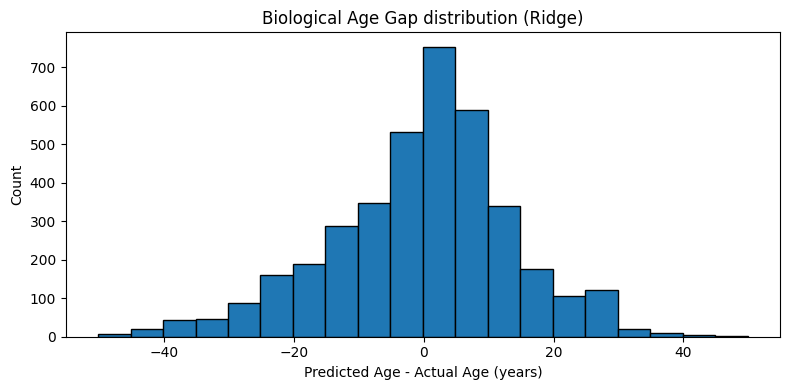

In [55]:
gap = (X_test_b @ best_w) - y_test
plt.figure(figsize = (8,4))
plt.hist(gap, bins = 20, edgecolor = 'black')

plt.title("Biological Age Gap distribution (Ridge)")
plt.xlabel("Predicted Age - Actual Age (years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()